<a href="https://colab.research.google.com/github/CodeWith-Sana/Learn-ML-WithSana/blob/main/Titanic_Dataset_Preprocessesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#loading The Libraries

In [5]:
import numpy as np
import pandas as pd


# Load the Titanic dataset into a DataFrame

In [6]:
# Load the Titanic dataset into a DataFrame
data = pd.DataFrame(pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Titanic Machine Dataset/train.csv'))


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Display data types of all columns

In [9]:
print(data.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## Check For Missing Values

In [10]:
print(data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [11]:
print(data)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [12]:
#dealing With Null Values

data["Age"].fillna(data["Age"].median(), inplace=True)

/tmp/ipykernel_582/1133161081.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].median(), inplace=True)


In [13]:
data['Age'].isnull().sum()

np.int64(0)

In [14]:
# Column Embarked

data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)

/tmp/ipykernel_582/1124018451.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)


### Decision on the 'Cabin' Column: Extract Deck and Drop Original

**Choice:** Extract the first letter as a new `Deck` feature, fill missing values with an 'Unknown' category, and drop the original `Cabin` column.

**Justification:**
1. **High Missingness (Structural Data Missing):** Over 77% of the `Cabin` values are missing. In the Titanic, cabin records were predominantly preserved for first-class passengers who survived. The missingness itself carries a strong signal (Missing = Likely Lower Class / Non-Survivor).
2. **High Cardinality:** The raw `Cabin` column contains too many unique strings (e.g., 'C23', 'E46'). Feeding these directly into a machine learning model would lead to severe overfitting.
3. **Information Extraction:** The first letter of the cabin represents the deck level (A through G). Deck location is highly correlated with socio-economic status and proximity to the lifeboats, making it a powerful feature for predicting survival.
4. **Conclusion:** Transforming `Cabin` into a simplified `Deck` variable preserves the predictive power of the location and the structural missingness while eliminating the high cardinality that harms model performance.


In [15]:
# Column cabin

# 1. Extract the deck letter (first letter of the cabin)
# If the value is missing (NaN), we label it 'Unknown'
data['Deck'] = data['Cabin'].astype(str).str[0]
data['Deck'] = data['Deck'].replace('n', 'Unknown')

# 2. Drop the original Cabin column
data.drop(columns=['Cabin'], inplace=True)

# Verify the changes
print(data['Deck'].value_counts())

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


In [16]:
# Drop PassengerId from the dataset
data.drop(columns=['PassengerId'], inplace=True)

In [17]:
data.head(30)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Unknown
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Unknown
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Unknown
5,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,Unknown
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,E
7,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,Unknown
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,Unknown
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,Unknown


In [18]:
data.duplicated().sum()

np.int64(0)

## Sex Column → Use Label Encoding
## The Sex column only has two unique values: male and female.
## The Embarked Column → Use One-Hot EncodingThe Embarked column has three unique values representing ports: C (Cherbourg), Q (Queenstown), and S (Southampton).


In [19]:
from sklearn.preprocessing import LabelEncoder
# 1. Label Encoding for 'Sex' (Binary)
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])

# 2. One-Hot Encoding for 'Embarked' (Multi-class, Unordered)
# Note: drop_first=True prevents the "dummy variable trap" by dropping one redundant column
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True)


In [20]:

# View the results
print(data[['Sex', 'Embarked_Q', 'Embarked_S']].head())

   Sex  Embarked_Q  Embarked_S
0    1       False        True
1    0       False       False
2    0       False        True
3    0       False        True
4    1       False        True


In [21]:
data.head(20)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Deck,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,False,False
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C,False,True
4,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,False,True
5,0,3,"Moran, Mr. James",1,28.0,0,0,330877,8.4583,Unknown,True,False
6,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.8625,E,False,True
7,0,3,"Palsson, Master. Gosta Leonard",1,2.0,3,1,349909,21.0750,Unknown,False,True
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,27.0,0,2,347742,11.1333,Unknown,False,True
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",0,14.0,1,0,237736,30.0708,Unknown,False,False


In [22]:
from sklearn.preprocessing import StandardScaler
# --- STEP 2: Feature Scaling for 'Age' and 'Fare' ---
# Initialize the StandardScaler (makes mean = 0 and variance = 1)
scaler = StandardScaler()

# Scale both numerical columns together
data[['Age', 'Fare']] = scaler.fit_transform(data[['Age', 'Fare']])


# --- Verify the Results ---
print(data[['Age', 'Fare']].head())

        Age      Fare
0 -0.565736 -0.502445
1  0.663861  0.786845
2 -0.258337 -0.488854
3  0.433312  0.420730
4  0.433312 -0.486337


<Axes: xlabel='Age', ylabel='Count'>

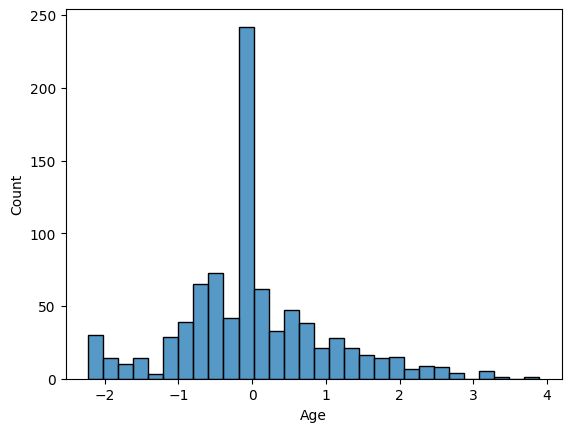

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data["Age"])

In [24]:
print(data[['Age', 'Fare']].describe())

                Age          Fare
count  8.910000e+02  8.910000e+02
mean   2.272780e-16  3.987333e-18
std    1.000562e+00  1.000562e+00
min   -2.224156e+00 -6.484217e-01
25%   -5.657365e-01 -4.891482e-01
50%   -1.046374e-01 -3.573909e-01
75%    4.333115e-01 -2.424635e-02
max    3.891554e+00  9.667167e+00


In [25]:
print(data[['Age', 'Fare']].mean())
print(data[['Age', 'Fare']].std())

Age     2.272780e-16
Fare    3.987333e-18
dtype: float64
Age     1.000562
Fare    1.000562
dtype: float64


In [26]:
print(data)

     Survived  Pclass                                               Name  Sex  \
0           0       3                            Braund, Mr. Owen Harris    1   
1           1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0   
2           1       3                             Heikkinen, Miss. Laina    0   
3           1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0   
4           0       3                           Allen, Mr. William Henry    1   
..        ...     ...                                                ...  ...   
886         0       2                              Montvila, Rev. Juozas    1   
887         1       1                       Graham, Miss. Margaret Edith    0   
888         0       3           Johnston, Miss. Catherine Helen "Carrie"    0   
889         1       1                              Behr, Mr. Karl Howell    1   
890         0       3                                Dooley, Mr. Patrick    1   

          Age  SibSp  Parch

In [27]:
import pandas as pd
import numpy as np

# 1. Create FamilySize
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

# 2. Create IsAlone (1 if alone, 0 if with family)
data['IsAlone'] = 0
data.loc[data['FamilySize'] == 1, 'IsAlone'] = 1

# 3. Extract Titles from the Name column
# This looks for words ending with a period (like Mr.)
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles (like Lady, Countess, Capt) into standard categories
data['Title'] = data['Title'].replace(['Lady', 'Countess','Capt', 'Col',
                                       'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

# Fix inconsistent titles
data['Title'] = data['Title'].replace('Mlle', 'Miss')
data['Title'] = data['Title'].replace('Ms', 'Miss')
data['Title'] = data['Title'].replace('Mme', 'Mrs')

# One-Hot Encode the new Title column so the model can read it
data = pd.get_dummies(data, columns=['Title'], drop_first=True)

# 4. Drop the columns we no longer need
# We drop Name because we extracted Title.
# We drop Ticket because it is chaotic text with little predictive power.
data.drop(columns=['Name', 'Ticket'], inplace=True)

# Preview your engineered dataset
print(data.head())


   Survived  Pclass  Sex       Age  SibSp  Parch      Fare     Deck  \
0         0       3    1 -0.565736      1      0 -0.502445  Unknown   
1         1       1    0  0.663861      1      0  0.786845        C   
2         1       3    0 -0.258337      0      0 -0.488854  Unknown   
3         1       1    0  0.433312      1      0  0.420730        C   
4         0       3    1  0.433312      0      0 -0.486337  Unknown   

   Embarked_Q  Embarked_S  FamilySize  IsAlone  Title_Miss  Title_Mr  \
0       False        True           2        0       False      True   
1       False       False           2        0       False     False   
2       False        True           1        1        True     False   
3       False        True           2        0       False     False   
4       False        True           1        1       False      True   

   Title_Mrs  Title_Rare  
0      False       False  
1       True       False  
2      False       False  
3       True       False  
4    

<>:13: SyntaxWarning: invalid escape sequence '\.'
<>:13: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_582/1326250436.py:13: SyntaxWarning: invalid escape sequence '\.'
  data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [28]:
data.head(20)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Deck,Embarked_Q,Embarked_S,FamilySize,IsAlone,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,1,-0.565736,1,0,-0.502445,Unknown,False,True,2,0,False,True,False,False
1,1,1,0,0.663861,1,0,0.786845,C,False,False,2,0,False,False,True,False
2,1,3,0,-0.258337,0,0,-0.488854,Unknown,False,True,1,1,True,False,False,False
3,1,1,0,0.433312,1,0,0.420730,C,False,True,2,0,False,False,True,False
4,0,3,1,0.433312,0,0,-0.486337,Unknown,False,True,1,1,False,True,False,False
5,0,3,1,-0.104637,0,0,-0.478116,Unknown,True,False,1,1,False,True,False,False
6,0,1,1,1.893459,0,0,0.395814,E,False,True,1,1,False,True,False,False
7,0,3,1,-2.102733,3,1,-0.224083,Unknown,False,True,5,0,False,False,False,False
8,1,3,0,-0.181487,0,2,-0.424256,Unknown,False,True,3,0,False,False,True,False
9,1,2,0,-1.180535,1,0,-0.042956,Unknown,False,False,2,0,False,False,True,False


##Feature Engineering

In [30]:
from sklearn.model_selection import train_test_split

# 1. Drop redundant columns used to make FamilySize
# This prevents multicollinearity (confusing the model with duplicate information)
X = data.drop(columns=['Survived', 'SibSp', 'Parch'])
# 2. Separate our target variable (what we want to predict)
y = data['Survived']

In [32]:
X

,Pclass,Sex,Age,Fare,Deck,Embarked_Q,Embarked_S,FamilySize,IsAlone,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,1,-0.565736,-0.502445,Unknown,False,True,2,0,False,True,False,False
1,1,0,0.663861,0.786845,C,False,False,2,0,False,False,True,False
2,3,0,-0.258337,-0.488854,Unknown,False,True,1,1,True,False,False,False
3,1,0,0.433312,0.420730,C,False,True,2,0,False,False,True,False
4,3,1,0.433312,-0.486337,Unknown,False,True,1,1,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,1,-0.181487,-0.386671,Unknown,False,True,1,1,False,False,False,True
887,1,0,-0.796286,-0.044381,B,False,True,1,1,True,False,False,False
888,3,0,-0.104637,-0.176263,Unknown,False,True,4,0,True,False,False,False
889,1,1,-0.258337,-0.044381,C,False,False,1,1,False,True,False,False


In [33]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [34]:
# 3. Split the data into Training (80%) and Testing (20%) sets
# random_state=42 ensures you get the exact same split every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Verify the Shapes ---
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")
print(f"Training Labels Shape:   {y_train.shape}")

Training Features Shape: (712, 13)
Testing Features Shape:  (179, 13)
Training Labels Shape:   (712,)
